# Entrenamiento ML - Maiz (dataset por hoja)

Este notebook entrena modelos para predecir el tratamiento en maiz usando el dataset por hoja (`leaf_stats`).

Incluye:
- validaciones de integridad del split por objeto
- exploracion de distribuciones y correlacion
- reduccion de features por correlacion alta
- comparacion de modelos con y sin reduccion

In [1]:
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, cohen_kappa_score
from sklearn.base import clone

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGBClassifier = None
    XGB_AVAILABLE = False
    print("Aviso: xgboost no esta instalado; el modelo XGB sera omitido.")

warnings.filterwarnings("ignore")


In [2]:
# Rutas del dataset por hoja
TRAIN_PATH = "datasets/dataset_maiz_leaf_stats_train_v1.csv"
TEST_PATH = "datasets/dataset_maiz_leaf_stats_test_v1.csv"
MANIFEST_PATH = "datasets/object_split_maiz_leaf_stats_v1.csv"

assert os.path.exists(TRAIN_PATH), f"No existe {TRAIN_PATH}"
assert os.path.exists(TEST_PATH), f"No existe {TEST_PATH}"
assert os.path.exists(MANIFEST_PATH), f"No existe {MANIFEST_PATH}"

df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)
manifest = pd.read_csv(MANIFEST_PATH)

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
print("Manifest shape:", manifest.shape)

Train shape: (401, 88)
Test shape: (172, 88)
Manifest shape: (573, 3)


## 1. QA de integridad

In [3]:
def qa_split_integrity(train_df: pd.DataFrame, test_df: pd.DataFrame, split_manifest: pd.DataFrame):
    print("=== QA split por objeto ===")

    ids_train = set(train_df["object_id"].astype(str).unique())
    ids_test = set(test_df["object_id"].astype(str).unique())
    overlap = ids_train & ids_test
    print("Object IDs train:", len(ids_train))
    print("Object IDs test:", len(ids_test))
    print("Overlap train/test:", len(overlap))
    assert len(overlap) == 0, "Hay fuga de object_id entre train y test"

    merged = pd.concat([train_df, test_df], ignore_index=True).copy()
    merged["object_id"] = merged["object_id"].astype(str)

    map_manifest = split_manifest.copy()
    map_manifest["object_id"] = map_manifest["object_id"].astype(str)
    split_map = map_manifest.set_index("object_id")["split"].to_dict()

    split_from_manifest = merged["object_id"].map(split_map)
    mismatch = int((split_from_manifest != merged["split"]).sum())
    print("Mismatch split vs manifest:", mismatch)
    assert mismatch == 0, "La columna split no coincide con el manifest"

    print("Distribucion por tratamiento y split (objetos unicos):")
    tmp = merged[["object_id", "tratamiento", "split"]].drop_duplicates()
    print(tmp.groupby(["tratamiento", "split"]).size().unstack(fill_value=0).to_string())

qa_split_integrity(df_train, df_test, manifest)

=== QA split por objeto ===
Object IDs train: 401
Object IDs test: 172
Overlap train/test: 0
Mismatch split vs manifest: 0
Distribucion por tratamiento y split (objetos unicos):
split        test  train
tratamiento             
1              55    130
2              50    116
3              34     78
4              33     77


## 2. Seleccion de variables

In [4]:
TARGET_COL = "tratamiento"
EXCLUDE_COLS = ["cultivo", "fecha", "nombre_imagen", "object_id", "split"]

feature_cols = [
    c for c in df_train.columns
    if c not in EXCLUDE_COLS + [TARGET_COL]
]

# Mantener solo columnas numericas
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_train[c])]

print("Total features iniciales:", len(feature_cols))
print("Ejemplo de features:", feature_cols[:12])

Total features iniciales: 82
Ejemplo de features: ['genotipo', 'n_pixels', 'int_444_mean', 'int_444_median', 'int_444_std', 'int_444_p10', 'int_444_p25', 'int_444_p75', 'int_444_p90', 'int_444_cv', 'int_475_mean', 'int_475_median']


## 3. Exploracion rapida y correlacion

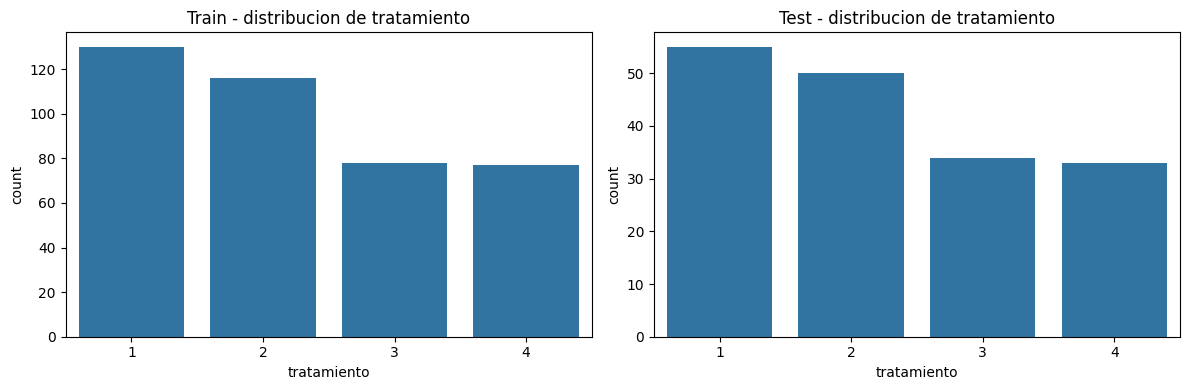

In [5]:
# Distribucion de clases
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=TARGET_COL, data=df_train, ax=ax[0])
ax[0].set_title("Train - distribucion de tratamiento")
sns.countplot(x=TARGET_COL, data=df_test, ax=ax[1])
ax[1].set_title("Test - distribucion de tratamiento")
plt.tight_layout()
plt.show()

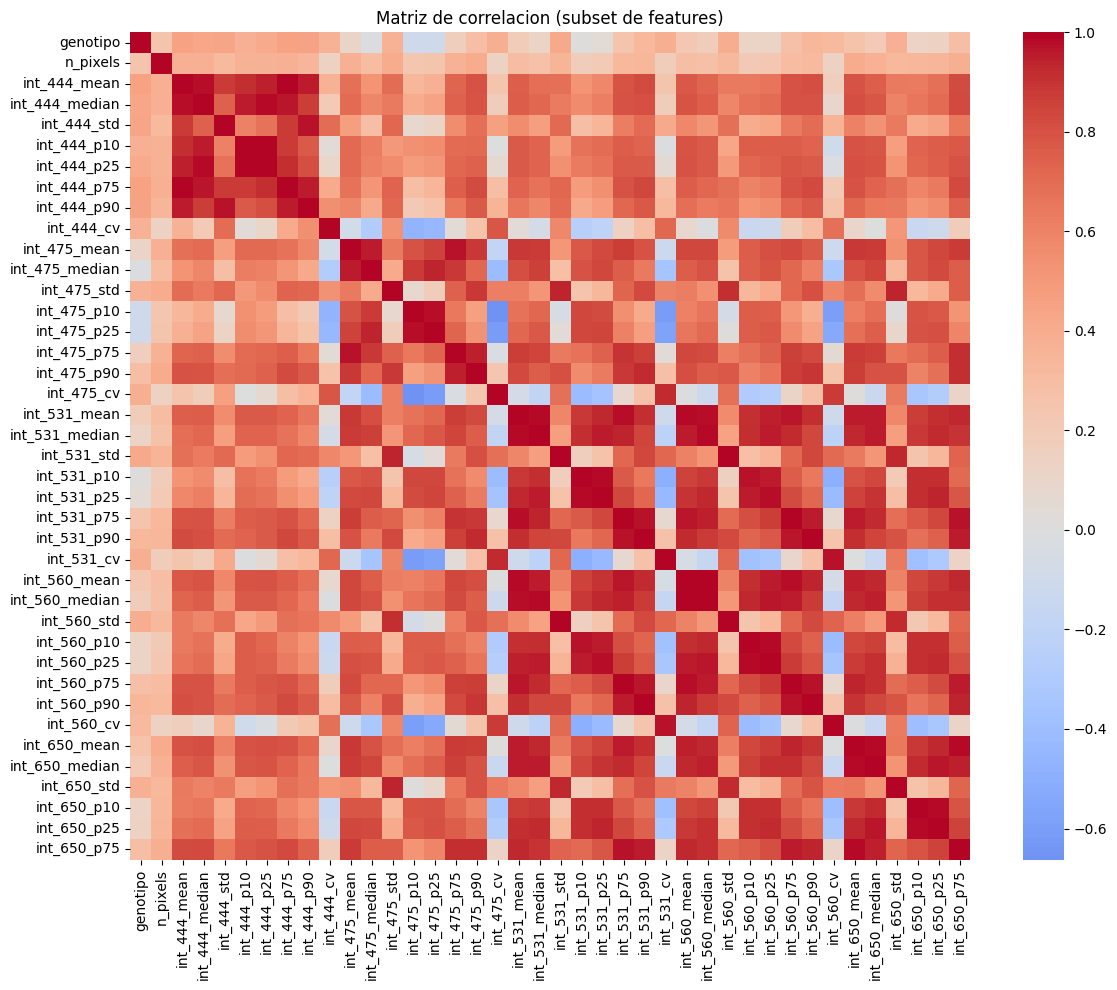

In [6]:
# Correlacion entre features (muestra de las primeras 40 para visualizacion)
corr_subset = feature_cols[:40] if len(feature_cols) > 40 else feature_cols
corr_mx = df_train[corr_subset].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_mx, cmap="coolwarm", center=0)
plt.title("Matriz de correlacion (subset de features)")
plt.tight_layout()
plt.show()

In [7]:
def reducir_por_correlacion(train_df: pd.DataFrame, cols: list, threshold: float = 0.95) -> tuple[list, list]:
    """Elimina variables altamente correlacionadas en train para evitar alta dimensionalidad redundante."""
    corr_abs = train_df[cols].corr().abs()
    upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > threshold)]
    selected = [c for c in cols if c not in to_drop]
    return selected, to_drop

CORR_THRESHOLD = 0.95
feature_cols_reduced, dropped_corr = reducir_por_correlacion(df_train, feature_cols, threshold=CORR_THRESHOLD)

print(f"Features originales: {len(feature_cols)}")
print(f"Features tras reduccion por correlacion (>{CORR_THRESHOLD}): {len(feature_cols_reduced)}")
print(f"Features eliminadas: {len(dropped_corr)}")
print("Ejemplo eliminadas:", dropped_corr[:15])

Features originales: 82
Features tras reduccion por correlacion (>0.95): 24
Features eliminadas: 58
Ejemplo eliminadas: ['int_444_median', 'int_444_p10', 'int_444_p25', 'int_444_p75', 'int_444_p90', 'int_475_median', 'int_475_p25', 'int_475_p75', 'int_531_median', 'int_531_p25', 'int_531_p75', 'int_531_p90', 'int_560_mean', 'int_560_median', 'int_560_std']


## 4. Entrenamiento de modelos (baseline vs reduccion)

In [8]:
le = LabelEncoder()
y_train = le.fit_transform(df_train[TARGET_COL])
y_test = le.transform(df_test[TARGET_COL])

X_train_base = df_train[feature_cols].copy()
X_test_base = df_test[feature_cols].copy()

X_train_red = df_train[feature_cols_reduced].copy()
X_test_red = df_test[feature_cols_reduced].copy()

models = {
    "RandomForest": RandomForestClassifier(n_estimators=400, random_state=42, class_weight="balanced"),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=7, weights="distance"))
    ]),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1200, random_state=42))
    ]),
}

if XGB_AVAILABLE:
    models["XGB"] = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        objective="multi:softprob",
        eval_metric="mlogloss",
    )
else:
    print("Modelo XGB omitido porque xgboost no esta disponible en el entorno.")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluar_escenario(Xtr, ytr, Xte, yte, escenario: str):
    rows = []
    fitted = {}
    for name, model in models.items():
        m = clone(model)
        cv_f1 = cross_val_score(m, Xtr, ytr, cv=cv, scoring="f1_macro").mean()
        m.fit(Xtr, ytr)
        pred = m.predict(Xte)
        rows.append({
            "escenario": escenario,
            "modelo": name,
            "cv_f1_macro": cv_f1,
            "test_acc": accuracy_score(yte, pred),
            "test_f1_macro": f1_score(yte, pred, average="macro"),
            "test_kappa": cohen_kappa_score(yte, pred),
        })
        fitted[name] = (m, pred)
    return pd.DataFrame(rows), fitted

res_base, fitted_base = evaluar_escenario(X_train_base, y_train, X_test_base, y_test, "sin_reduccion")
res_red, fitted_red = evaluar_escenario(X_train_red, y_train, X_test_red, y_test, "con_reduccion_corr")

results = pd.concat([res_base, res_red], ignore_index=True)
display(results.sort_values(["test_f1_macro", "test_acc"], ascending=False))


,escenario,modelo,cv_f1_macro,test_acc,test_f1_macro,test_kappa
0,sin_reduccion,RandomForest,0.592342,0.645349,0.638096,0.518958
3,sin_reduccion,XGB,0.603176,0.622093,0.608263,0.486614
2,sin_reduccion,MLP,0.682473,0.587209,0.581283,0.444657
7,con_reduccion_corr,XGB,0.485952,0.569767,0.580727,0.416174
4,con_reduccion_corr,RandomForest,0.466267,0.563953,0.564533,0.411684
1,sin_reduccion,KNN,0.523929,0.546512,0.544905,0.388514
6,con_reduccion_corr,MLP,0.555490,0.552326,0.543127,0.388013
5,con_reduccion_corr,KNN,0.457724,0.511628,0.506742,0.340906


### 4.1 Diagnóstico de posible sobreajuste (baseline)

Comparación de métricas en entrenamiento vs prueba para cada modelo baseline y escenario (sin reducción / con reducción).

In [ ]:
def metricas_train_test(modelo, Xtr, ytr, Xte, yte):
    """Entrena un modelo y retorna métricas en train y test para analizar gap."""
    m = clone(modelo)
    m.fit(Xtr, ytr)
    pred_tr = m.predict(Xtr)
    pred_te = m.predict(Xte)
    return {
        "train_acc": accuracy_score(ytr, pred_tr),
        "test_acc": accuracy_score(yte, pred_te),
        "train_f1_macro": f1_score(ytr, pred_tr, average="macro"),
        "test_f1_macro": f1_score(yte, pred_te, average="macro"),
        "train_kappa": cohen_kappa_score(ytr, pred_tr),
        "test_kappa": cohen_kappa_score(yte, pred_te),
    }

rows_gap = []

for escenario, Xtr, Xte in [
    ("sin_reduccion", X_train_base, X_test_base),
    ("con_reduccion_corr", X_train_red, X_test_red),
]:
    for nombre, modelo in models.items():
        mts = metricas_train_test(modelo, Xtr, y_train, Xte, y_test)
        rows_gap.append({
            "escenario": escenario,
            "modelo": nombre,
            **mts,
            "gap_f1_macro": mts["train_f1_macro"] - mts["test_f1_macro"],
            "gap_acc": mts["train_acc"] - mts["test_acc"],
        })

baseline_gap_df = pd.DataFrame(rows_gap).sort_values(["gap_f1_macro", "gap_acc"], ascending=False)
display(baseline_gap_df)

print("\nTop posibles sobreajustes (mayor gap_f1_macro):")
display(baseline_gap_df[["escenario", "modelo", "train_f1_macro", "test_f1_macro", "gap_f1_macro"]].head(5))

,escenario,modelo,train_acc,test_acc,train_f1_macro,test_f1_macro,train_kappa,test_kappa,gap_f1_macro,gap_acc
5,con_reduccion_corr,KNN,1.000000,0.511628,1.000000,0.506742,1.000000,0.340906,0.493258,0.488372
1,sin_reduccion,KNN,1.000000,0.546512,1.000000,0.544905,1.000000,0.388514,0.455095,0.453488
4,con_reduccion_corr,RandomForest,1.000000,0.563953,1.000000,0.564533,1.000000,0.411684,0.435467,0.436047
7,con_reduccion_corr,XGB,1.000000,0.569767,1.000000,0.580727,1.000000,0.416174,0.419273,0.430233
3,sin_reduccion,XGB,1.000000,0.622093,1.000000,0.608263,1.000000,0.486614,0.391737,0.377907
0,sin_reduccion,RandomForest,1.000000,0.645349,1.000000,0.638096,1.000000,0.518958,0.361904,0.354651
2,sin_reduccion,MLP,0.648379,0.587209,0.648644,0.581283,0.529570,0.444657,0.067361,0.061170
6,con_reduccion_corr,MLP,0.581047,0.552326,0.567860,0.543127,0.429978,0.388013,0.024733,0.028722



Top posibles sobreajustes (mayor gap_f1_macro):


,escenario,modelo,train_f1_macro,test_f1_macro,gap_f1_macro
5,con_reduccion_corr,KNN,1.0,0.506742,0.493258
1,sin_reduccion,KNN,1.0,0.544905,0.455095
4,con_reduccion_corr,RandomForest,1.0,0.564533,0.435467
7,con_reduccion_corr,XGB,1.0,0.580727,0.419273
3,sin_reduccion,XGB,1.0,0.608263,0.391737


In [10]:
# Seleccionar mejor modelo por test_f1_macro
best_row = results.sort_values("test_f1_macro", ascending=False).iloc[0]
best_scenario = best_row["escenario"]
best_model_name = best_row["modelo"]

print("Mejor escenario:", best_scenario)
print("Mejor modelo:", best_model_name)

if best_scenario == "sin_reduccion":
    best_model, best_pred = fitted_base[best_model_name]
else:
    best_model, best_pred = fitted_red[best_model_name]

print("\nReporte de clasificacion (test):")
print(classification_report(y_test, best_pred, target_names=[str(c) for c in le.classes_]))

Mejor escenario: sin_reduccion
Mejor modelo: RandomForest

Reporte de clasificacion (test):
              precision    recall  f1-score   support

           1       0.66      0.71      0.68        55
           2       0.69      0.62      0.65        50
           3       0.56      0.56      0.56        34
           4       0.65      0.67      0.66        33

    accuracy                           0.65       172
   macro avg       0.64      0.64      0.64       172
weighted avg       0.65      0.65      0.64       172



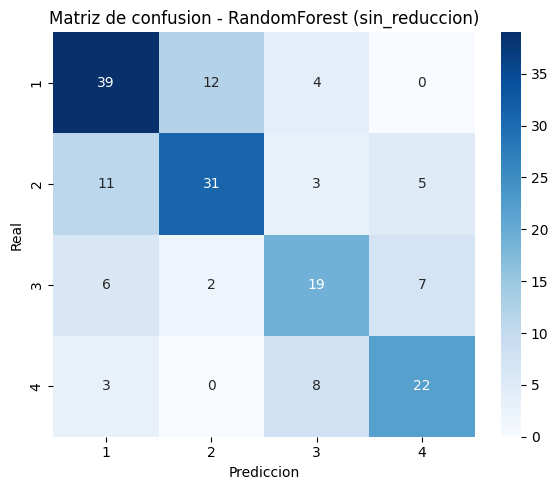

In [11]:
# Matriz de confusion del mejor modelo
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title(f"Matriz de confusion - {best_model_name} ({best_scenario})")
plt.tight_layout()
plt.show()

## 4.2 Ajuste de hiperparametros (RandomizedSearchCV)

Se realiza busqueda aleatoria de hiperparametros en ambos escenarios:
- sin reduccion
- con reduccion por correlacion

Adicionalmente, se reporta el trade-off entre mejora de test F1 y reduccion del gap de sobreajuste.

In [12]:
# Tuning en ambos escenarios: sin reduccion y con reduccion por correlacion
escenarios_tuning = {
    "sin_reduccion": (X_train_base, X_test_base),
    "con_reduccion_corr": (X_train_red, X_test_red),
}

param_spaces = {
    "RandomForest": {
        "n_estimators": [200, 400, 700],
        "max_depth": [None, 12, 20, 30],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 3, 5],
        "max_features": ["sqrt", "log2", 0.5, 0.7],
        "class_weight": ["balanced", "balanced_subsample"],
    },
    "KNN": {
        "clf__n_neighbors": [5, 7, 11, 15, 21, 31],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2],
    },
    "MLP": {
        "clf__hidden_layer_sizes": [(64,), (96, 48), (128, 64), (128, 64, 32)],
        "clf__alpha": [1e-4, 1e-3, 3e-3, 1e-2, 3e-2],
        "clf__learning_rate_init": [1e-4, 3e-4, 1e-3, 3e-3],
        "clf__batch_size": [32, 64, 128],
        "clf__early_stopping": [True],
        "clf__validation_fraction": [0.15, 0.20],
        "clf__n_iter_no_change": [15, 25],
        "clf__max_iter": [1500],
    },
}

if XGB_AVAILABLE:
    param_spaces["XGB"] = {
        "n_estimators": [150, 300, 500, 800],
        "max_depth": [4, 6, 8, 10],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
        "min_child_weight": [1, 3, 5],
        "gamma": [0.0, 0.1, 0.3],
        "reg_alpha": [0.0, 0.01, 0.1],
        "reg_lambda": [0.1, 0.5, 1.0, 2.0],
    }

cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
N_ITER = 35
TOP_K_CANDIDATES = 8
GAP_PENALTY = 0.10

tuning_rows = []
best_tuned_models = {}

for escenario, (Xtr_tune, Xte_tune) in escenarios_tuning.items():
    X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
        Xtr_tune,
        y_train,
        test_size=0.20,
        stratify=y_train,
        random_state=42,
    )

    for model_name, model_obj in models.items():
        if model_name not in param_spaces:
            continue

        print(f"\n=== Tuning {model_name} | escenario={escenario} ===")
        rs = RandomizedSearchCV(
            estimator=model_obj,
            param_distributions=param_spaces[model_name],
            n_iter=N_ITER,
            scoring="f1_macro",
            cv=cv_tune,
            random_state=42,
            n_jobs=-1,
            verbose=0,
            refit=False,
        )
        rs.fit(X_tune_train, y_tune_train)

        cv_results = pd.DataFrame(rs.cv_results_).sort_values("rank_test_score")
        candidatos = cv_results.head(TOP_K_CANDIDATES)

        best_candidate = None
        best_obj = -np.inf

        for _, cand in candidatos.iterrows():
            cand_params = cand["params"]
            est = clone(model_obj).set_params(**cand_params)
            est.fit(X_tune_train, y_tune_train)

            pred_train_c = est.predict(X_tune_train)
            pred_val_c = est.predict(X_tune_val)

            train_f1_c = f1_score(y_tune_train, pred_train_c, average="macro")
            val_f1_c = f1_score(y_tune_val, pred_val_c, average="macro")
            gap_train_val_c = train_f1_c - val_f1_c

            obj_score = val_f1_c - GAP_PENALTY * max(0.0, gap_train_val_c)

            if obj_score > best_obj:
                best_obj = obj_score
                best_candidate = {
                    "model": est,
                    "params": cand_params,
                    "cv_f1": float(cand["mean_test_score"]),
                    "train_f1": train_f1_c,
                    "val_f1": val_f1_c,
                    "gap_train_val": gap_train_val_c,
                    "obj_score": obj_score,
                }

        # Diagnosticos en subconjunto de validacion (modelo entrenado en 80% del train)
        pred_train = best_candidate["model"].predict(X_tune_train)
        pred_val = best_candidate["model"].predict(X_tune_val)
        train_f1_partial = f1_score(y_tune_train, pred_train, average="macro")
        val_f1 = f1_score(y_tune_val, pred_val, average="macro")

        # Reentrenar con mejores hiperparametros sobre el train completo para evaluacion final
        best_model = clone(model_obj).set_params(**best_candidate["params"])
        best_model.fit(Xtr_tune, y_train)
        pred_train_full = best_model.predict(Xtr_tune)
        pred_test = best_model.predict(Xte_tune)
        train_f1 = f1_score(y_train, pred_train_full, average="macro")
        test_f1 = f1_score(y_test, pred_test, average="macro")

        row = {
            "escenario": escenario,
            "modelo": model_name,
            "best_cv_f1_macro": best_candidate["cv_f1"],
            "selection_objective": best_candidate["obj_score"],
            "train_f1_macro": train_f1,
            "val_f1_macro": val_f1,
            "test_f1_macro": test_f1,
            "gap_train_val_f1": train_f1_partial - val_f1,
            "gap_f1_macro": train_f1 - test_f1,
            "test_acc": accuracy_score(y_test, pred_test),
            "test_kappa": cohen_kappa_score(y_test, pred_test),
            "best_params": json.dumps(best_candidate["params"], default=str),
        }
        tuning_rows.append(row)
        best_tuned_models[(escenario, model_name)] = {
            "search": rs,
            "model": best_model,
            "pred_test": pred_test,
        }

        print(f"CV F1-macro (candidato): {best_candidate['cv_f1']:.4f}")
        print(f"Val F1-macro: {val_f1:.4f}")
        print(f"Test F1-macro: {test_f1:.4f}")
        print(f"Gap train-val F1: {row['gap_train_val_f1']:.4f}")
        print(f"Gap train-test F1: {row['gap_f1_macro']:.4f}")

tuning_results_df = pd.DataFrame(tuning_rows)
tuning_results_df = tuning_results_df.sort_values(
    ["escenario", "selection_objective", "val_f1_macro", "test_f1_macro"],
    ascending=[True, False, False, False],
)

display(tuning_results_df[[
    "escenario",
    "modelo",
    "best_cv_f1_macro",
    "selection_objective",
    "val_f1_macro",
    "train_f1_macro",
    "test_f1_macro",
    "gap_train_val_f1",
    "gap_f1_macro",
    "test_acc",
    "test_kappa",
]])



=== Tuning RandomForest | escenario=sin_reduccion ===
CV F1-macro (candidato): 0.5656
Val F1-macro: 0.6318
Test F1-macro: 0.6422
Gap train-val F1: 0.3650
Gap train-test F1: 0.3552

=== Tuning KNN | escenario=sin_reduccion ===
CV F1-macro (candidato): 0.4804
Val F1-macro: 0.5627
Test F1-macro: 0.5095
Gap train-val F1: 0.1406
Gap train-test F1: 0.2235

=== Tuning MLP | escenario=sin_reduccion ===
CV F1-macro (candidato): 0.6098
Val F1-macro: 0.6229
Test F1-macro: 0.6754
Gap train-val F1: 0.2911
Gap train-test F1: 0.2703

=== Tuning XGB | escenario=sin_reduccion ===
CV F1-macro (candidato): 0.5889
Val F1-macro: 0.6568
Test F1-macro: 0.6097
Gap train-val F1: 0.3342
Gap train-test F1: 0.3714

=== Tuning RandomForest | escenario=con_reduccion_corr ===
CV F1-macro (candidato): 0.4951
Val F1-macro: 0.4930
Test F1-macro: 0.5781
Gap train-val F1: 0.4759
Gap train-test F1: 0.4016

=== Tuning KNN | escenario=con_reduccion_corr ===
CV F1-macro (candidato): 0.4162
Val F1-macro: 0.4640
Test F1-macro

,escenario,modelo,best_cv_f1_macro,selection_objective,val_f1_macro,train_f1_macro,test_f1_macro,gap_train_val_f1,gap_f1_macro,test_acc,test_kappa
6,con_reduccion_corr,MLP,0.472440,0.547566,0.577883,0.840812,0.583618,0.303167,0.257194,0.593023,0.444777
7,con_reduccion_corr,XGB,0.498538,0.454239,0.501087,0.962532,0.570134,0.468477,0.392399,0.569767,0.414966
5,con_reduccion_corr,KNN,0.416240,0.452048,0.463999,0.651331,0.505340,0.119503,0.145991,0.517442,0.342877
4,con_reduccion_corr,RandomForest,0.495115,0.445363,0.492953,0.979661,0.578054,0.475897,0.401607,0.581395,0.439105
3,sin_reduccion,XGB,0.588942,0.623403,0.656820,0.981138,0.609724,0.334175,0.371415,0.616279,0.480386
0,sin_reduccion,RandomForest,0.565589,0.595251,0.631752,0.997422,0.642199,0.365008,0.355223,0.651163,0.527732
2,sin_reduccion,MLP,0.609784,0.593824,0.622931,0.945647,0.675354,0.291065,0.270293,0.680233,0.564757
1,sin_reduccion,KNN,0.480438,0.548682,0.562746,0.732994,0.509486,0.140641,0.223508,0.517442,0.340509


In [13]:
# Comparacion tuning vs baseline por mismo escenario/modelo + baseline global
baseline_ref = baseline_gap_df[[
    "escenario", "modelo", "test_f1_macro", "test_acc", "test_kappa", "gap_f1_macro"
]].copy().rename(columns={
    "test_f1_macro": "baseline_test_f1_macro",
    "test_acc": "baseline_test_acc",
    "test_kappa": "baseline_test_kappa",
    "gap_f1_macro": "baseline_gap_f1_macro",
})

comparacion_tuning = tuning_results_df.merge(
    baseline_ref,
    on=["escenario", "modelo"],
    how="left",
)

comparacion_tuning = comparacion_tuning.rename(columns={
    "test_f1_macro": "tuned_test_f1_macro",
    "test_acc": "tuned_test_acc",
    "test_kappa": "tuned_test_kappa",
})

# Trade-off explicito: mejora en test F1 y reduccion del gap de sobreajuste
comparacion_tuning["delta_test_f1_vs_baseline"] = (
    comparacion_tuning["tuned_test_f1_macro"] - comparacion_tuning["baseline_test_f1_macro"]
)
comparacion_tuning["delta_gap_f1_vs_baseline"] = (
    comparacion_tuning["baseline_gap_f1_macro"] - comparacion_tuning["gap_f1_macro"]
)
comparacion_tuning["tradeoff_testf1_mas_reduccion_gap"] = (
    comparacion_tuning["delta_test_f1_vs_baseline"] + comparacion_tuning["delta_gap_f1_vs_baseline"]
)

best_baseline_global = results.sort_values("test_f1_macro", ascending=False).iloc[0]
comparacion_tuning["best_baseline_global_modelo"] = best_baseline_global["modelo"]
comparacion_tuning["best_baseline_global_escenario"] = best_baseline_global["escenario"]
comparacion_tuning["best_baseline_global_test_f1"] = float(best_baseline_global["test_f1_macro"])
comparacion_tuning["delta_test_f1_vs_best_baseline_global"] = (
    comparacion_tuning["tuned_test_f1_macro"] - comparacion_tuning["best_baseline_global_test_f1"]
)

comparacion_tuning = comparacion_tuning.sort_values(
    ["tradeoff_testf1_mas_reduccion_gap", "tuned_test_f1_macro"], ascending=False
)

display(comparacion_tuning[[
    "escenario",
    "modelo",
    "baseline_test_f1_macro",
    "tuned_test_f1_macro",
    "delta_test_f1_vs_baseline",
    "baseline_gap_f1_macro",
    "gap_f1_macro",
    "delta_gap_f1_vs_baseline",
    "tradeoff_testf1_mas_reduccion_gap",
    "delta_test_f1_vs_best_baseline_global",
]])

out_cmp = "results/training_results_maiz_leaf_stats_v1_tuning_comparison.csv"
comparacion_tuning.to_csv(out_cmp, index=False)
print(f"Comparacion tuning/baseline guardada en: {out_cmp}")

ganador_tradeoff = comparacion_tuning.iloc[0]
print("\nMejor candidato por trade-off:")
print({
    "escenario": ganador_tradeoff["escenario"],
    "modelo": ganador_tradeoff["modelo"],
    "tuned_test_f1_macro": float(ganador_tradeoff["tuned_test_f1_macro"]),
    "delta_test_f1_vs_baseline": float(ganador_tradeoff["delta_test_f1_vs_baseline"]),
    "delta_gap_f1_vs_baseline": float(ganador_tradeoff["delta_gap_f1_vs_baseline"]),
    "delta_test_f1_vs_best_baseline_global": float(ganador_tradeoff["delta_test_f1_vs_best_baseline_global"]),
})

,escenario,modelo,baseline_test_f1_macro,tuned_test_f1_macro,delta_test_f1_vs_baseline,baseline_gap_f1_macro,gap_f1_macro,delta_gap_f1_vs_baseline,tradeoff_testf1_mas_reduccion_gap,delta_test_f1_vs_best_baseline_global
2,con_reduccion_corr,KNN,0.506742,0.505340,-0.001402,0.493258,0.145991,0.347267,0.345864,-0.132755
7,sin_reduccion,KNN,0.544905,0.509486,-0.035419,0.455095,0.223508,0.231587,0.196168,-0.128610
3,con_reduccion_corr,RandomForest,0.564533,0.578054,0.013521,0.435467,0.401607,0.033859,0.047380,-0.060042
4,sin_reduccion,XGB,0.608263,0.609724,0.001461,0.391737,0.371415,0.020322,0.021783,-0.028372
1,con_reduccion_corr,XGB,0.580727,0.570134,-0.010594,0.419273,0.392399,0.026874,0.016280,-0.067962
5,sin_reduccion,RandomForest,0.638096,0.642199,0.004103,0.361904,0.355223,0.006681,0.010785,0.004103
6,sin_reduccion,MLP,0.581283,0.675354,0.094071,0.067361,0.270293,-0.202932,-0.108861,0.037259
0,con_reduccion_corr,MLP,0.543127,0.583618,0.040491,0.024733,0.257194,-0.232461,-0.191969,-0.054478


Comparacion tuning/baseline guardada en: results/training_results_maiz_leaf_stats_v1_tuning_comparison.csv

Mejor candidato por trade-off:
{'escenario': 'con_reduccion_corr', 'modelo': 'KNN', 'tuned_test_f1_macro': 0.5053401227782912, 'delta_test_f1_vs_baseline': -0.0014022545626777294, 'delta_gap_f1_vs_baseline': 0.34726650408468296, 'delta_test_f1_vs_best_baseline_global': -0.1327553903680514}


## 5. Análisis de importancia de features

Se analiza la relevancia de cada variable usando:
- **Importancia built-in** (impureza de Gini para RandomForest, gain para XGB): disponible solo en los modelos de árboles.
- **Ranking consenso**: importancias normalizadas y promediadas entre todos los modelos/escenarios con soporte built-in.


In [ ]:

# Importancia built-in desde modelos tuneados (RF y XGB)
importance_records = []

def extraer_importancias(model, feat_names, model_name, escenario):
    clf = model
    if hasattr(clf, "named_steps"):
        clf = clf.named_steps.get("clf", clf)
    if hasattr(clf, "feature_importances_"):
        return pd.DataFrame({
            "feature": feat_names,
            "importance": clf.feature_importances_,
            "modelo": model_name,
            "escenario": escenario,
        })
    return None

for (esc, mname), info in best_tuned_models.items():
    feat_names = feature_cols if esc == "sin_reduccion" else feature_cols_reduced
    df_imp = extraer_importancias(info["model"], feat_names, mname, esc)
    if df_imp is not None:
        importance_records.append(df_imp)

if importance_records:
    imp_df = pd.concat(importance_records, ignore_index=True)
    print(f"Modelos con importancia built-in: {imp_df['modelo'].unique().tolist()}")
    print(f"Total registros: {len(imp_df)}")
else:
    print("Ningún modelo tuneado soporta importancia built-in.")
    imp_df = pd.DataFrame()

Modelos con importancia built-in: ['RandomForest', 'XGB']
Total registros: 212


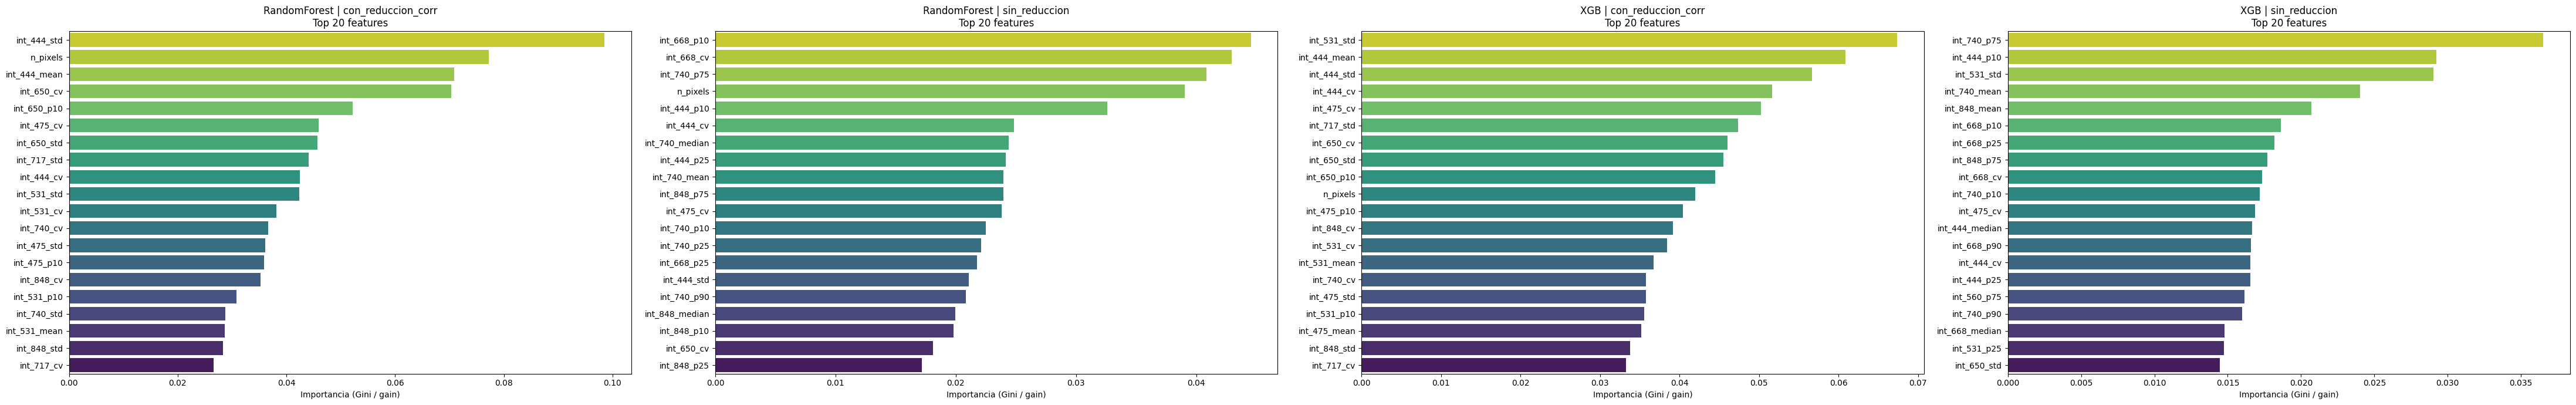

In [ ]:
TOP_N = 20

if not imp_df.empty:
    combos = list(imp_df.groupby(["modelo", "escenario"]))
    n_combos = len(combos)
    fig, axes = plt.subplots(1, n_combos, figsize=(11 * n_combos, 7))
    if n_combos == 1:
        axes = [axes]

    for ax, ((mname, esc), grp) in zip(axes, combos):
        top = grp.sort_values("importance", ascending=False).head(TOP_N)
        sns.barplot(data=top, x="importance", y="feature", ax=ax, palette="viridis_r")
        ax.set_title(f"{mname} | {esc}\nTop {TOP_N} features")
        ax.set_xlabel("Importancia (Gini / gain)")
        ax.set_ylabel("")

    plt.tight_layout()
    plt.show()
else:
    print("No hay importancias built-in disponibles para graficar.")


Top 20 features por ranking consenso:


,feature,consensus_mean,consensus_std,n_modelos
8,int_444_std,0.046770,0.039704,4
81,n_pixels,0.042590,0.026704,4
70,int_740_p75,0.038691,0.003057,2
24,int_531_std,0.036902,0.024548,4
33,int_650_cv,0.036448,0.027107,4
2,int_444_mean,0.036317,0.034376,4
9,int_475_cv,0.034197,0.016349,4
1,int_444_cv,0.033867,0.016022,4
44,int_668_p10,0.031580,0.018307,2
4,int_444_p10,0.030904,0.002385,2


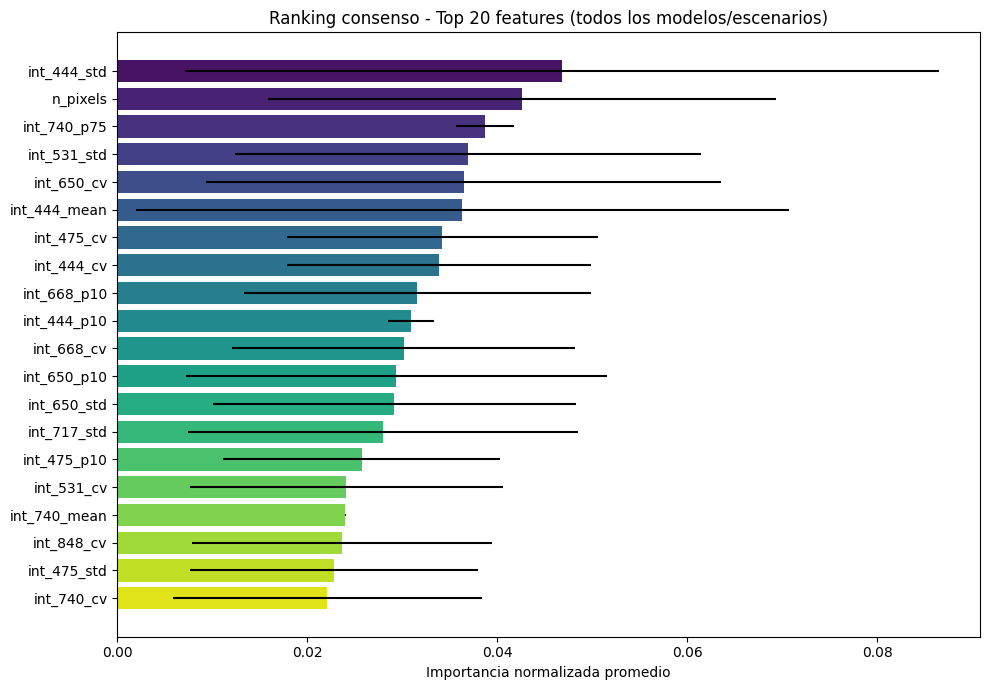

In [ ]:
# Ranking consenso: normalizar importancia por modelo/escenario y promediar
if not imp_df.empty:
    imp_df["importance_norm"] = imp_df.groupby(["modelo", "escenario"])["importance"].transform(
        lambda x: x / x.sum() if x.sum() > 0 else x
    )

    consensus = (
        imp_df.groupby("feature")["importance_norm"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={"mean": "consensus_mean", "std": "consensus_std", "count": "n_modelos"})
        .sort_values("consensus_mean", ascending=False)
    )

    print("Top 20 features por ranking consenso:")
    display(consensus.head(20))

    top_consensus = consensus.head(TOP_N)
    plt.figure(figsize=(10, 7))
    plt.barh(
        top_consensus["feature"].iloc[::-1],
        top_consensus["consensus_mean"].iloc[::-1],
        xerr=top_consensus["consensus_std"].iloc[::-1],
        color=sns.color_palette("viridis_r", TOP_N),
        align="center",
    )
    plt.xlabel("Importancia normalizada promedio")
    plt.title(f"Ranking consenso - Top {TOP_N} features (todos los modelos/escenarios)")
    plt.tight_layout()
    plt.show()
else:
    print("No hay importancias disponibles para el ranking consenso.")


### 5.1 SHAP values

SHAP (SHapley Additive exPlanations) permite interpretar **en qué dirección** influye cada feature:

- **Beeswarm plot**: cada punto es una muestra; el color indica el valor de la feature (rojo = alto, azul = bajo); la posición en X indica si el efecto empuja la predicción hacia esa clase o la aleja.
- **Bar plot (mean |SHAP|)**: magnitud promedio del efecto, equivalente a importancia de Gini pero basada en contribuciones reales a la predicción.
- Se usa `TreeExplainer` (exacto y rápido) para RandomForest y XGB. KNN y MLP requieren `PermutationExplainer` (más lento) y se omiten aquí.
- Los beeswarm se muestran **por clase** para el mejor modelo tuneado.


In [18]:

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP no está instalado. Instala con: pip install shap")

SHAP_BG_SAMPLES = 200  # muestras de fondo para TreeExplainer
shap_records = {}

if SHAP_AVAILABLE and not imp_df.empty:
    for (esc_s, mname_s), info_s in best_tuned_models.items():
        model_s = info_s["model"]
        feat_names_s = feature_cols if esc_s == "sin_reduccion" else feature_cols_reduced
        Xtr_s = X_train_base if esc_s == "sin_reduccion" else X_train_red
        Xte_s = X_test_base if esc_s == "sin_reduccion" else X_test_red

        clf_s = model_s
        if hasattr(clf_s, "named_steps"):
            clf_s = clf_s.named_steps.get("clf", clf_s)
        if not hasattr(clf_s, "feature_importances_"):
            continue  # solo RF y XGB soportan TreeExplainer

        bg = Xtr_s.sample(min(SHAP_BG_SAMPLES, len(Xtr_s)), random_state=42)
        try:
            explainer = shap.TreeExplainer(clf_s, data=bg, feature_names=feat_names_s)
            sv = explainer(Xte_s)
            shap_records[(esc_s, mname_s)] = {
                "shap_values": sv,
                "feat_names": feat_names_s,
            }
            print(f"SHAP calculado: {mname_s} | {esc_s}  — shape: {sv.values.shape}")
        except Exception as e:
            print(f"Error SHAP {mname_s}/{esc_s}: {e}")
elif not SHAP_AVAILABLE:
    print("Instala shap para continuar: pip install shap")
else:
    print("imp_df vacío: no hay modelos con importancia built-in, saltando SHAP.")


SHAP calculado: RandomForest | sin_reduccion  — shape: (172, 82, 4)
SHAP calculado: XGB | sin_reduccion  — shape: (172, 82, 4)


 98%|===================| 671/688 [00:18<00:00]        

SHAP calculado: RandomForest | con_reduccion_corr  — shape: (172, 24, 4)


 98%|===================| 672/688 [00:20<00:00]        

SHAP calculado: XGB | con_reduccion_corr  — shape: (172, 24, 4)


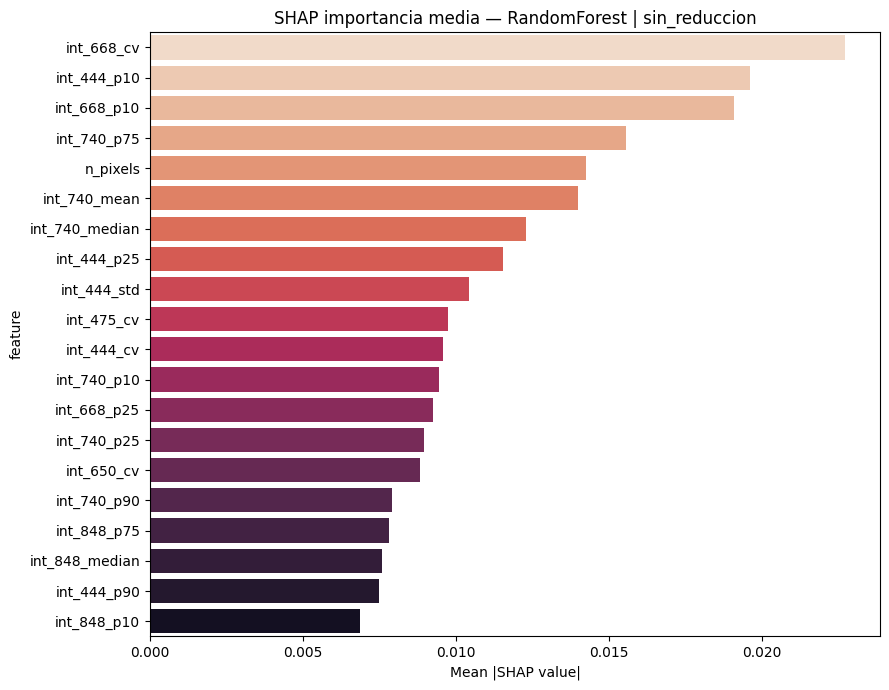

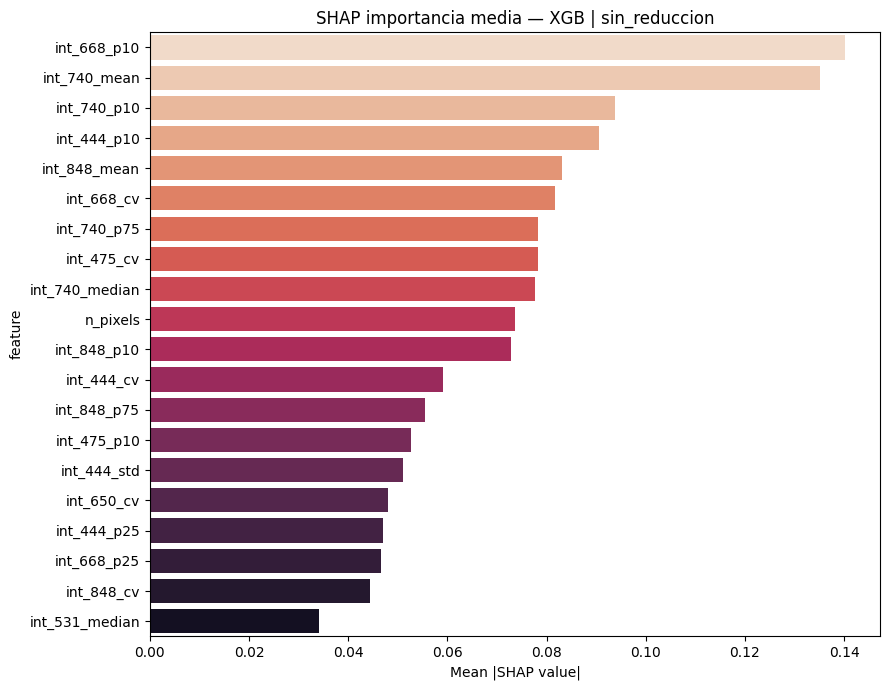

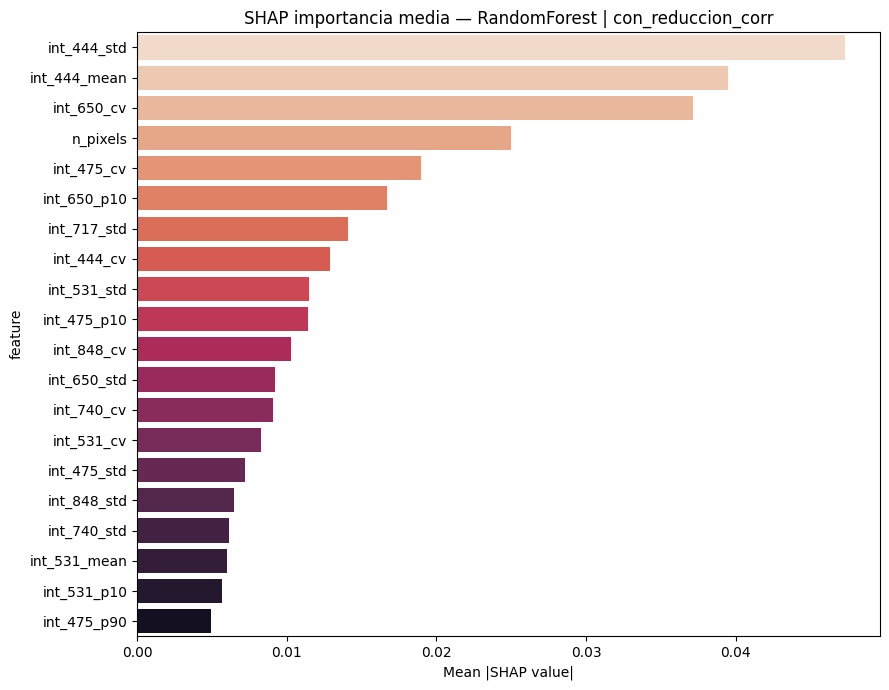

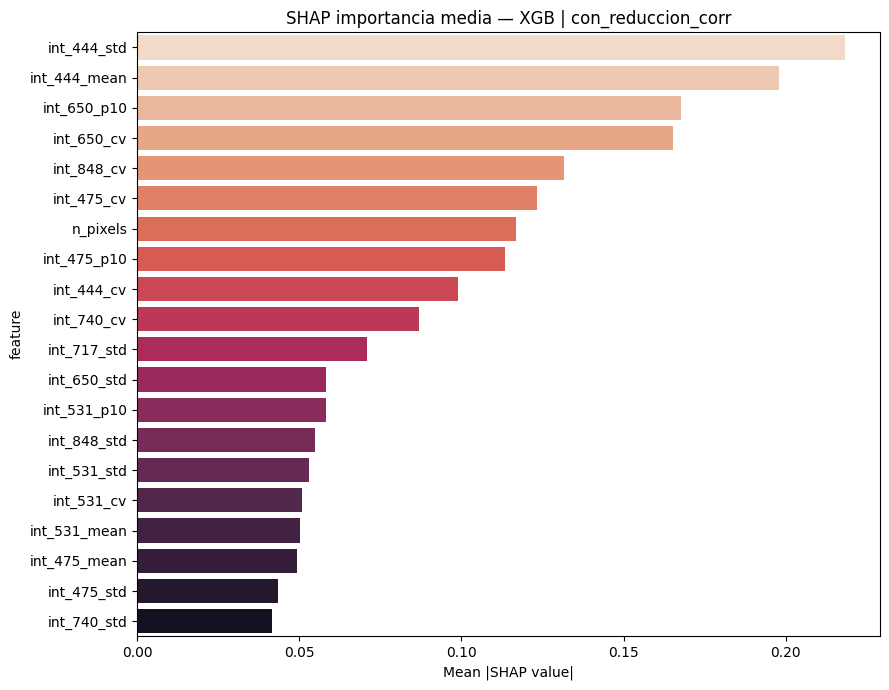


Beeswarm por clase — RandomForest | sin_reduccion


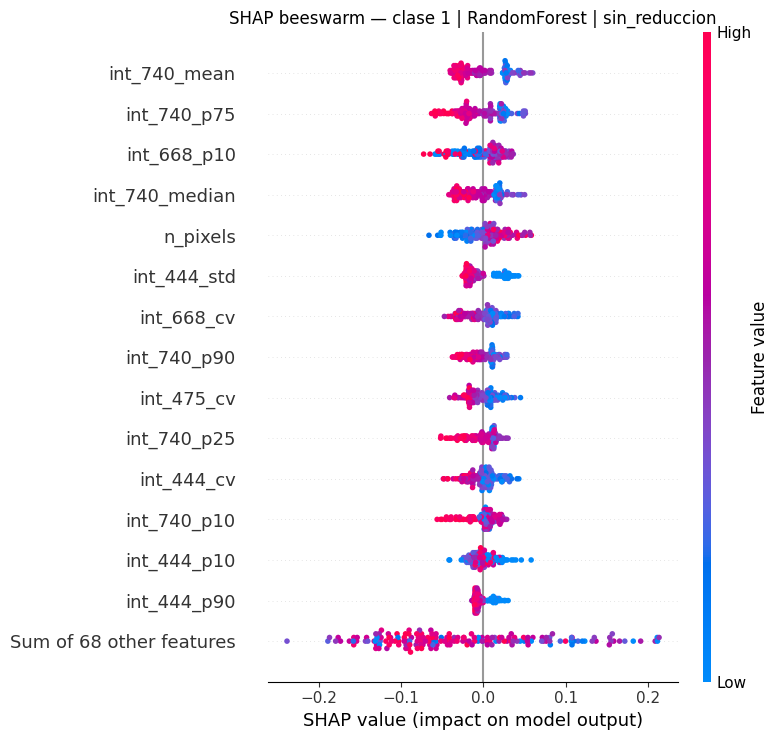

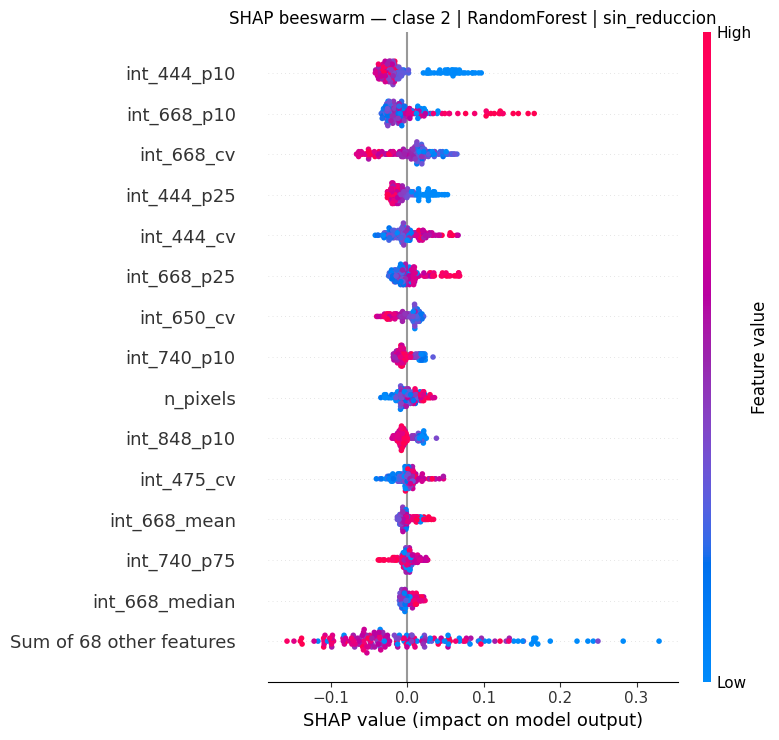

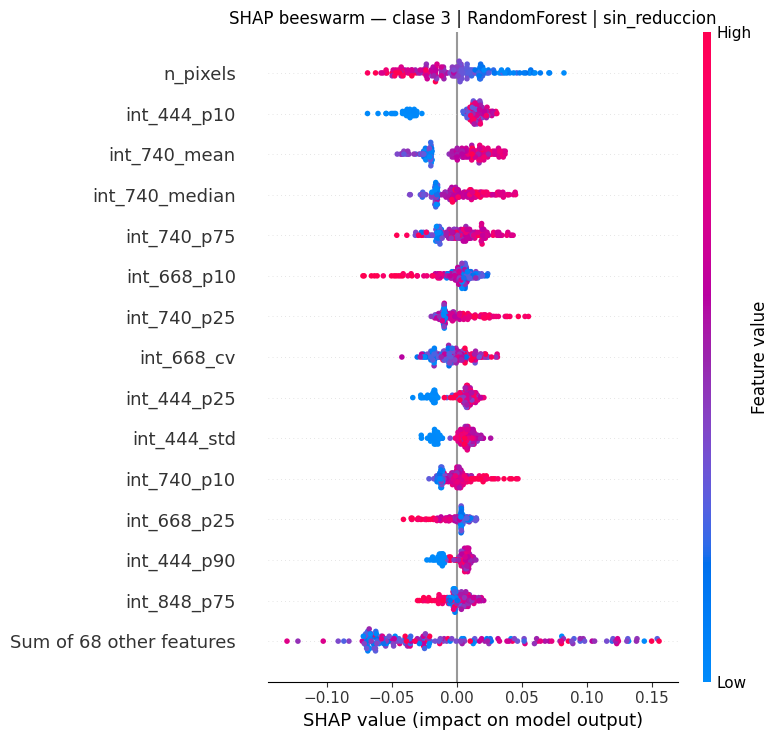

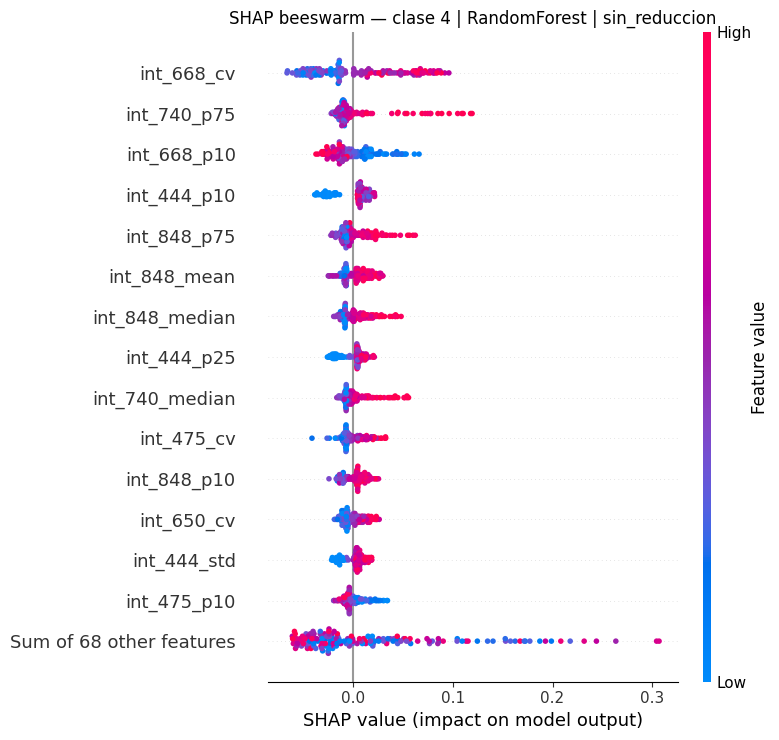

In [ ]:
if SHAP_AVAILABLE and shap_records:
    # --- 1. Bar plot: media |SHAP| por modelo/escenario ---
    for (esc_s, mname_s), rec in shap_records.items():
        sv = rec["shap_values"]
        feat_names_s = rec["feat_names"]
        vals = sv.values  # (n_samples, n_features) or (n_samples, n_features, n_classes)
        mean_abs = np.abs(vals).mean(axis=(0, 2)) if vals.ndim == 3 else np.abs(vals).mean(axis=0)

        shap_bar = (
            pd.DataFrame({"feature": feat_names_s, "mean_abs_shap": mean_abs})
            .sort_values("mean_abs_shap", ascending=False)
            .head(TOP_N)
        )
        plt.figure(figsize=(9, 7))
        sns.barplot(data=shap_bar, x="mean_abs_shap", y="feature", palette="rocket_r")
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"SHAP importancia media — {mname_s} | {esc_s}")
        plt.tight_layout()
        plt.show()

    # --- 2. Beeswarm por clase — mejor modelo tuneado con SHAP ---
    def _best_f1(k):
        mask = (tuning_results_df["escenario"] == k[0]) & (tuning_results_df["modelo"] == k[1])
        vals_f1 = tuning_results_df.loc[mask, "test_f1_macro"].values
        return float(vals_f1[0]) if len(vals_f1) > 0 else 0.0

    best_shap_key = max(shap_records.keys(), key=_best_f1)
    rec_best = shap_records[best_shap_key]
    sv_best = rec_best["shap_values"]
    feat_best = rec_best["feat_names"]
    esc_best, mname_best = best_shap_key

    print(f"\nBeeswarm por clase — {mname_best} | {esc_best}")
    vals_b = sv_best.values
    base_b = sv_best.base_values
    data_b = sv_best.data

    if vals_b.ndim == 3:
        for i, cls in enumerate(le.classes_):
            bv = base_b[:, i] if base_b.ndim == 2 else base_b
            sv_cls = shap.Explanation(
                values=vals_b[:, :, i],
                base_values=bv,
                data=data_b,
                feature_names=feat_best,
            )
            plt.figure(figsize=(10, 7))
            shap.plots.beeswarm(sv_cls, max_display=15, show=False)
            plt.title(f"SHAP beeswarm — clase {cls} | {mname_best} | {esc_best}")
            plt.tight_layout()
            plt.show()
    else:
        plt.figure(figsize=(10, 7))
        shap.plots.beeswarm(sv_best, max_display=15, show=False)
        plt.title(f"SHAP beeswarm — {mname_best} | {esc_best}")
        plt.tight_layout()
        plt.show()

elif SHAP_AVAILABLE:
    print("No se generaron valores SHAP (ningún modelo compatible encontrado).")

## 5. Guardar resultados

Se guardan metricas comparativas para trazabilidad.

In [ ]:
os.makedirs("results", exist_ok=True)
out_results = "results/training_results_maiz_leaf_stats.csv"
results.to_csv(out_results, index=False)
print("Resultados guardados en:", out_results)

summary = {
    "best_scenario": best_scenario,
    "best_model": best_model_name,
    "best_test_f1_macro": float(best_row["test_f1_macro"]),
    "best_test_acc": float(best_row["test_acc"]),
    "n_features_original": int(len(feature_cols)),
    "n_features_reduced": int(len(feature_cols_reduced)),
    "n_features_dropped": int(len(dropped_corr)),
}
print(summary)

Resultados guardados en: results/training_results_maiz_leaf_stats_v1.csv
{'best_scenario': 'sin_reduccion', 'best_model': 'RandomForest', 'best_test_f1_macro': 0.6380955131463426, 'best_test_acc': 0.6453488372093024, 'n_features_original': 82, 'n_features_reduced': 24, 'n_features_dropped': 58}
